In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.config import DADOS_ORIGINAIS , DADOS_LIMPOS
from src.graficos import PALETTE , SCATTER_ALPHA

In [54]:
df = pd.read_csv(DADOS_ORIGINAIS)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [55]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [56]:
df.shape

(1000, 8)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [58]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [59]:
df.describe(exclude = 'number')

,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


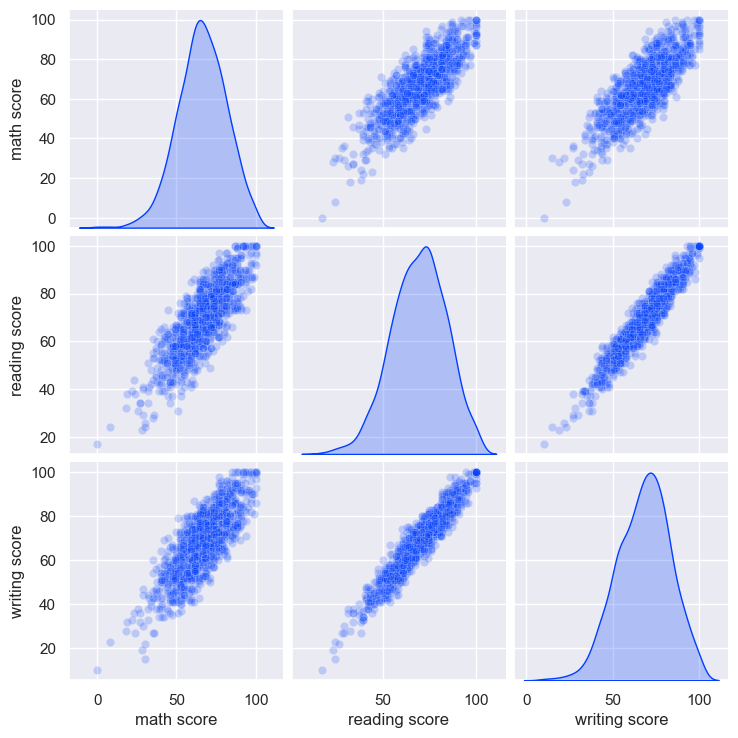

In [60]:
sns.pairplot(df , diag_kind = 'kde' , plot_kws = dict(alpha = SCATTER_ALPHA))

In [61]:
df.select_dtypes("number").skew()

math score      -0.278935
reading score   -0.259105
writing score   -0.289444
dtype: float64

In [62]:
df.select_dtypes("number").kurtosis()

math score       0.274964
reading score   -0.068265
writing score   -0.033365
dtype: float64

In [63]:
df[df.duplicated()]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score


In [64]:
df[df.isnull().any(axis = 1)]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score


In [65]:
df[df.isnull().any(axis = 1)].describe()

,math score,reading score,writing score
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


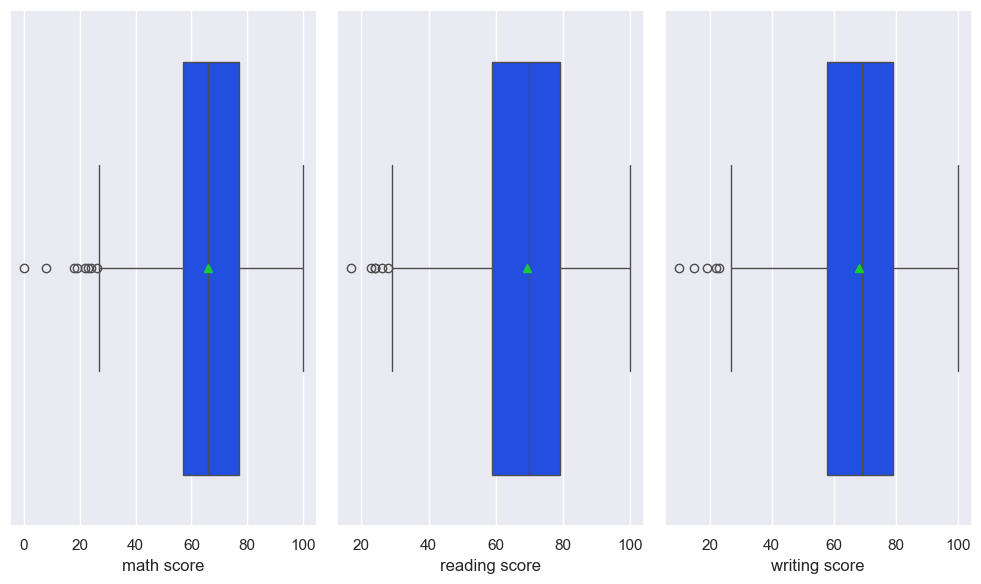

In [66]:
fig , axs = plt.subplots(1,3 , figsize = (10,6))

for ax , coluna in zip(axs.flatten() , df.select_dtypes(include= 'number').columns):
    sns.boxplot(data = df , x = coluna , ax = ax , showmeans = True)

plt.tight_layout()
plt.show()

<Axes: >

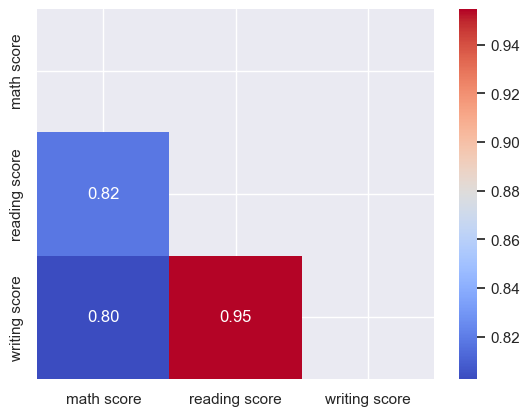

In [67]:
matriz = np.triu(df.select_dtypes("number").corr())

fig , ax = plt.subplots()

sns.heatmap(
    df.select_dtypes("number").corr(),
    mask = matriz, 
    annot = True,
    fmt = ".2f",
    ax = ax,
    cmap = PALETTE
)

<Axes: xlabel='gender'>

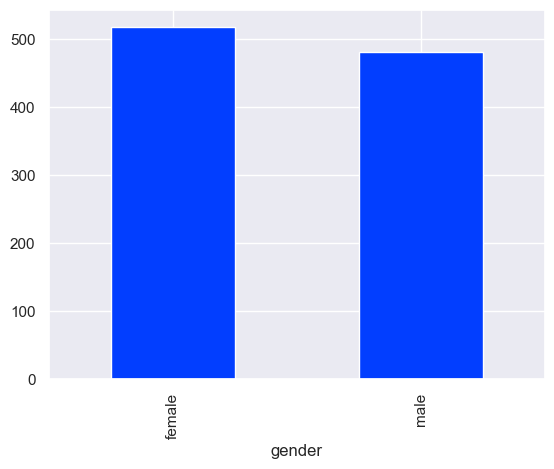

In [68]:
df['gender'].value_counts().sort_index().plot(kind = 'bar')

<Axes: xlabel='race/ethnicity'>

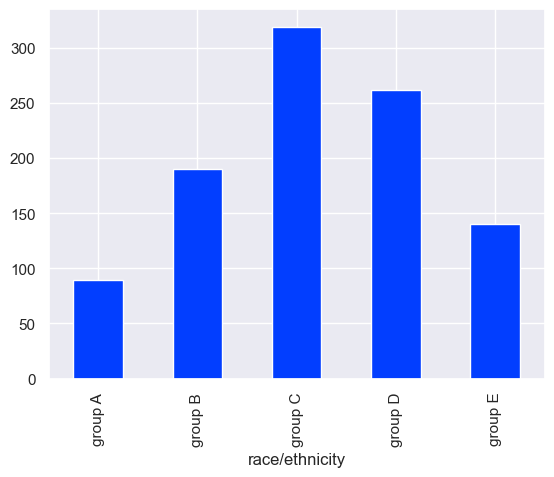

In [69]:
df['race/ethnicity'].value_counts().sort_index().plot(kind = 'bar')

In [70]:
df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

<Axes: xlabel='parental level of education'>

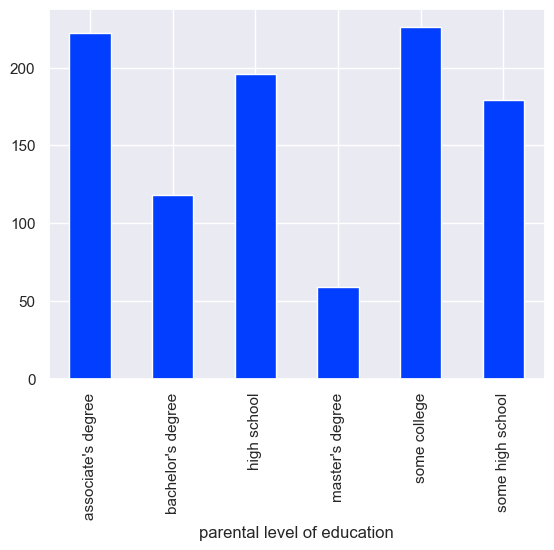

In [71]:
df['parental level of education'].value_counts().sort_index().plot(kind = 'bar')

<Axes: xlabel='lunch'>

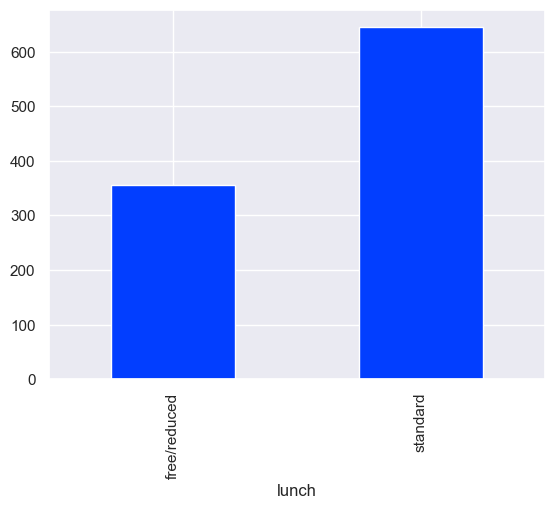

In [72]:
df['lunch'].value_counts().sort_index().plot(kind = 'bar')

<Axes: xlabel='test preparation course'>

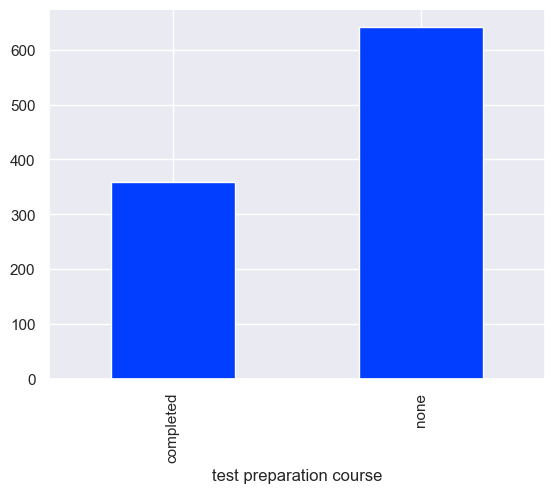

In [73]:
df['test preparation course'].value_counts().sort_index().plot(kind = 'bar')

In [74]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [76]:
df.to_parquet(DADOS_LIMPOS , index = False)